In [24]:
import os
import shutil
import glob
import pathlib
import glob


import pandas as pnd
import pysam
import pygenomeviz as pgv
import matplotlib.patches as patches


In [21]:
gal_deficient = pnd.read_excel('gal_deficiency/gal_deficient.xlsx', index_col=0).set_index('accession', drop=True)
print(len(gal_deficient))
gal_deficient

45


,strain,subspecies,cluster
accession,,,
GCA_949533805.1,extra-ERR982823.22_1677794525,Lr_murium,2
GCA_949350515.1,Tac401_18_Tac_co.27_1677235964,Lr_murium,2
GCA_948888645.1,MGBC101615,Lr_murium,2
GCA_948485015.1,MGBC106162,Lr_murium,2
GCA_004553055.1,W2P31.023,other_Lr,1
GCA_949380875.1,47_110627.52_1677753810,Lr_murium,2
GCA_949068065.1,MGBC126525,other_Lr,4
GCA_948693985.1,MGBC126820,Lr_rodentium,4
GCA_028721465.1,SUG1981,other_Lr,1


In [20]:
rpam = pnd.read_csv('gempipe/output_derive/rpam.csv', index_col=0)
rpam_gal =  rpam.loc[['GALt', 'GALM', 'GALK2', 'GALT', 'UDPG4E', 'GALU'], gal_deficient.index]
rpam_gal.T.describe()

,GALt,GALM,GALK2,GALT,UDPG4E,GALU
count,45.000000,45.000000,45.000000,45.0,45.0,45.0
mean,0.977778,0.044444,0.977778,1.0,1.0,1.0
std,0.149071,0.208409,0.149071,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,1.0,1.0,1.0
25%,1.000000,0.000000,1.000000,1.0,1.0,1.0
50%,1.000000,0.000000,1.000000,1.0,1.0,1.0
75%,1.000000,0.000000,1.000000,1.0,1.0,1.0
max,1.000000,1.000000,1.000000,1.0,1.0,1.0


In [5]:
os.makedirs('gal_deficiency',  exist_ok=True)
os.makedirs('gal_deficiency/genomes',  exist_ok=True)
os.makedirs('gal_deficiency/reference',  exist_ok=True)
os.makedirs('gal_deficiency/alignments',  exist_ok=True)


for acc in gal_deficient.index: 
    shutil.copyfile(f'genomes_tf/{acc}.fna', f'gal_deficiency/genomes/{acc}.fna')
    
    
# also copy the reference:
_ = shutil.copyfile(f'genomes_tf/GCA_000016825.1.fna', f'gal_deficiency/reference/GCA_000016825.1.fna')
_ = shutil.copyfile(f'gempipe/working/gff/GCA_000016825.1.gff', f'gal_deficiency/reference/GCA_000016825.1.gff')


In [6]:
%%capture
%%bash
# perform the alignment


for f in gal_deficiency/genomes/*.fna; do
    b=$(basename $f .fna);
    echo $b;
    minimap2 -ax asm5 gal_deficiency/reference/GCA_000016825.1.fna $f > gal_deficiency/alignments/${b}.sam;
done


In [7]:
# convert sam to sorted+indexed bam

for al in glob.glob('gal_deficiency/alignments/*.sam'): 
    acc = pathlib.Path(al).stem
    # sort replacing the original 
    pysam.sort("-o", al, al)
    # covert to bam
    pysam.view("-bS", "-o", al +'.bam', al, catch_stdout=False)
    # create the index 
    pysam.index(al +".bam")



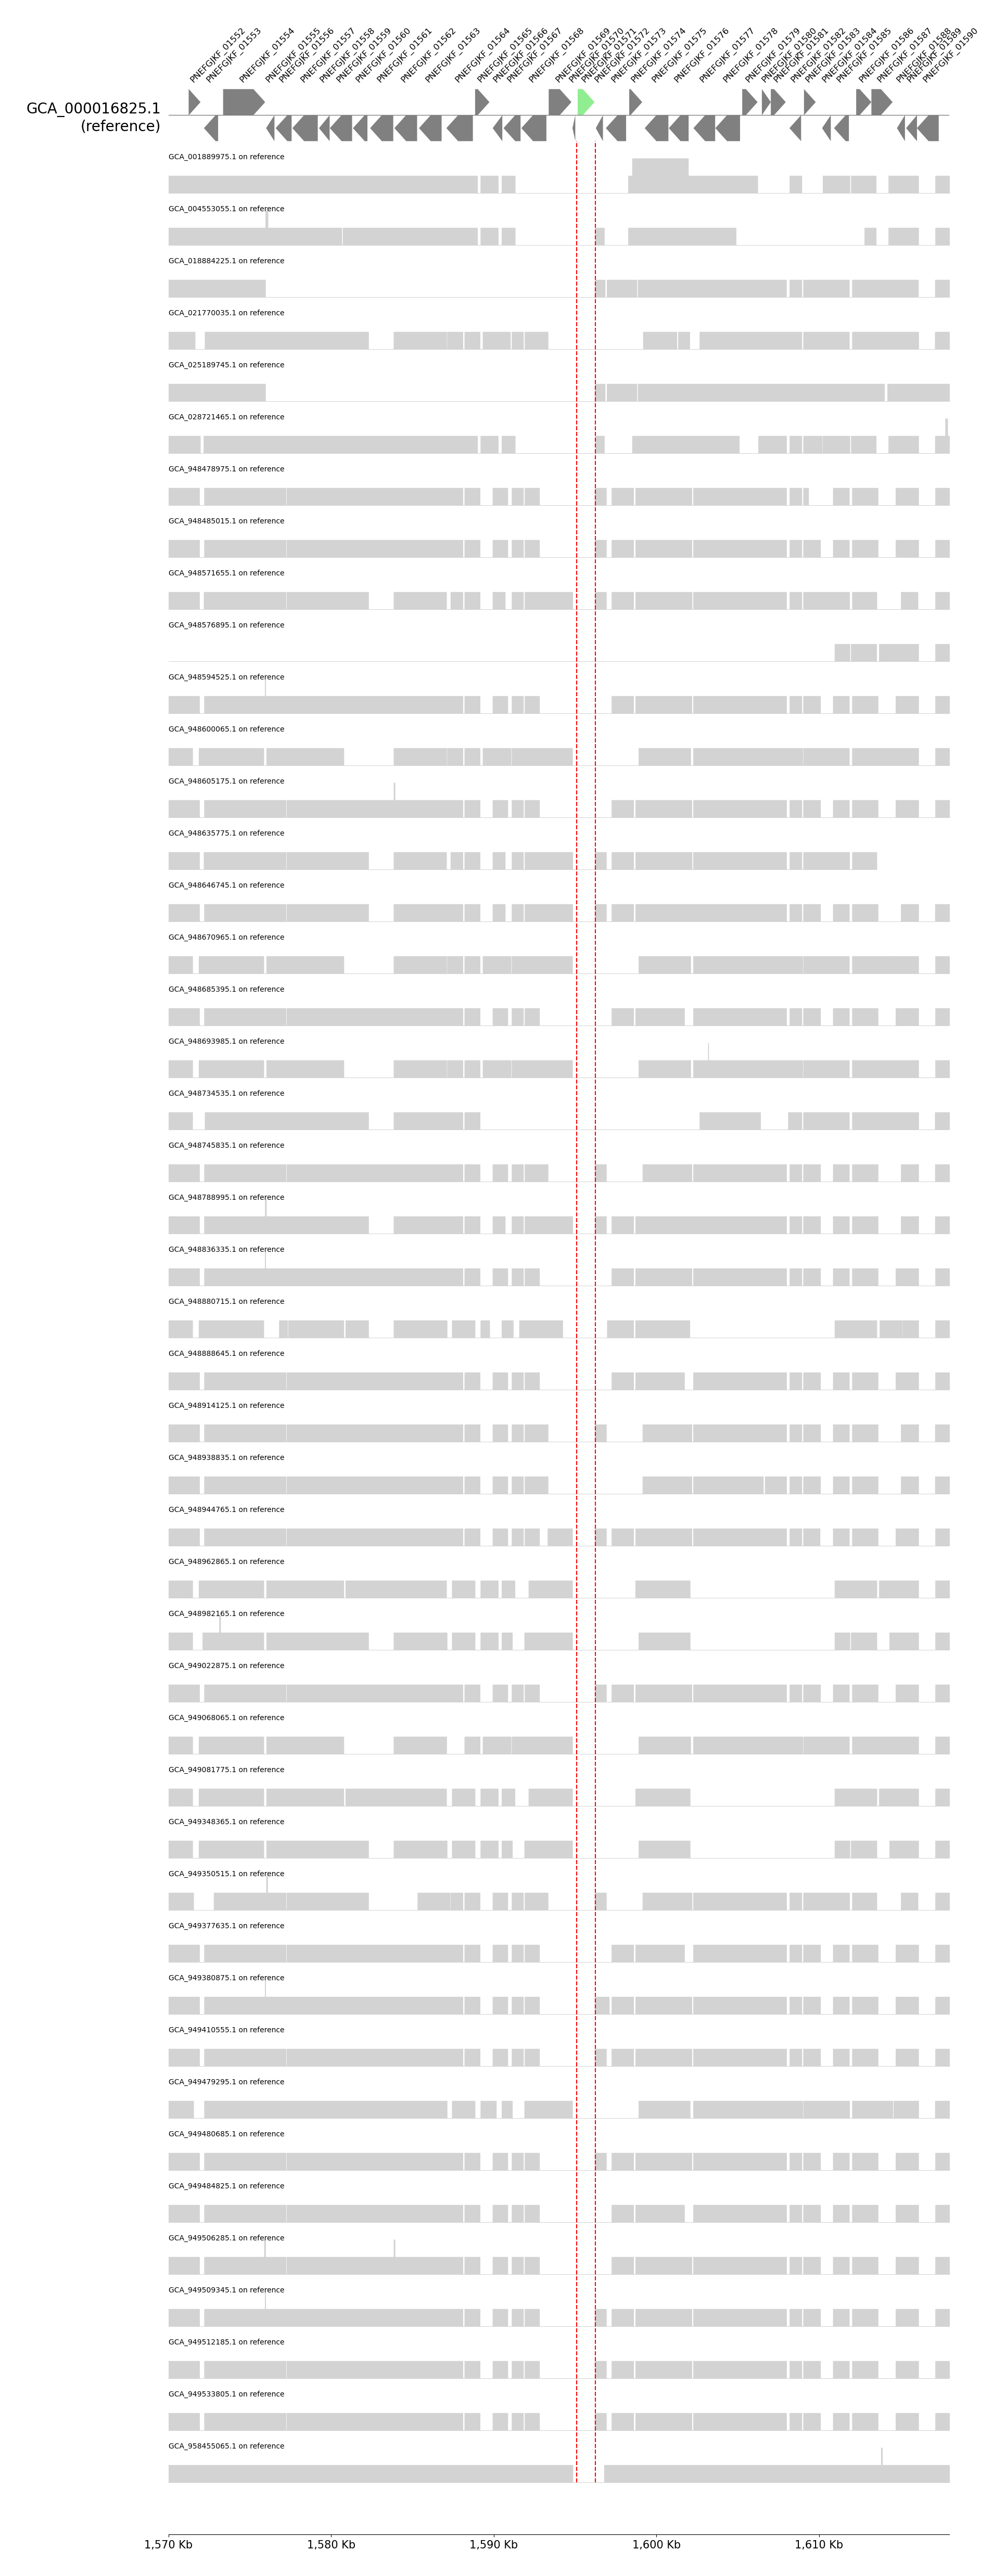

In [39]:


gff = pgv.parser.Gff('gal_deficiency/reference/GCA_000016825.1.gff')
gv = pgv.GenomeViz()
track_start = 1570000
track_end = 1618000
track = gv.add_feature_track(name='GCA_000016825.1\n(reference)', segments=(track_start, track_end))
gv.set_scale_xticks(start=track_start, unit='Kb')


# show features
for feature in gff.extract_features("CDS", target_range=(track_start, track_end)):

    color = 'grey'
    if feature.id == 'PNEFGJKF_01571': color = 'lightgreen'
    track.add_feature(
        feature.location.start, 
        feature.location.end, 
        feature.location.strand, 
        label=feature.id,
        arrow_shaft_ratio=1.0, color=color, text_kws=dict(rotation=45, vpos="top"))
    
    
# parse the pilup
acc_to_points = {}
for sam_file in glob.glob('gal_deficiency/alignments/*.sam'):
    acc = pathlib.Path(sam_file).stem
    
    with pysam.AlignmentFile(sam_file +'.bam', "rb") as bam:
        x, y = [], []
        cursor = track_start -1
        for pileupcolumn in bam.pileup("CP000705.1", track_start -1, track_end -1, truncate=True):  # 0-based index
            while cursor < pileupcolumn.pos:
                x.append(cursor +1)
                y.append(0)
                cursor += 1
            x.append(cursor +1)
            y.append(pileupcolumn.n)
            cursor += 1
            
        acc_to_points[acc] = (x, y)
acc_to_points = dict(sorted(acc_to_points.items()))


# create substracks
max_y = 0
for x, y in acc_to_points.values():
    if max(y) > max_y: max_y = max(y)
for acc in acc_to_points.keys():
    track.add_subtrack(ylim=(0, max_y +1), name=acc) 

fig = gv.plotfig()


# populate subtracks
for acc in acc_to_points.keys():
    
    subtrack = track.get_subtrack(acc)
    x, y = acc_to_points[acc]
    for segment in track.segments:
        
        x = segment.transform_coord(x)
        subtrack.ax.fill_between(x, y, color="lightgrey")
        subtrack.ax.text(x[0], max_y, f"{acc} on reference", color='black')

    
        # make red rectangle:
        subtrack.ax.vlines(25100, 0, max_y +1, linestyles='dashed', color='red')
        subtrack.ax.vlines(26250, 0, max_y +1, linestyles='dashed', color='red')